<a href="https://colab.research.google.com/github/vishakhacodes/Capstone_Experiments_DeepLearning/blob/main/Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name= Vishakha Gaur

### Roll No= 2501940065

---

### EXPERIMENT 3 (LSTM)

---

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0717 - val_loss: 0.0107
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0070 - val_loss: 0.0050
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0032 - val_loss: 0.0036
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0030 - val_loss: 0.0035
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0

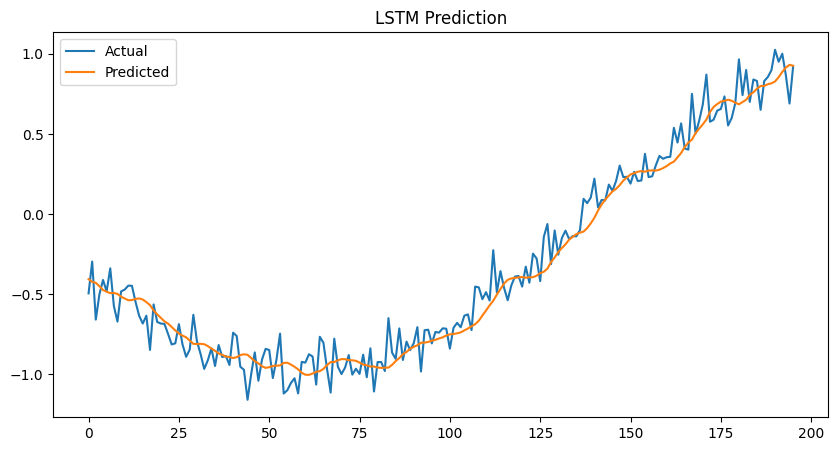

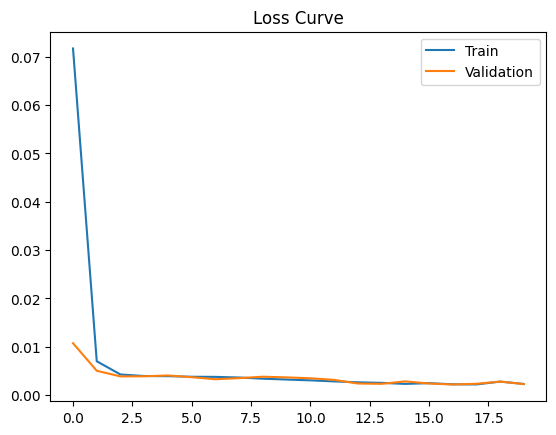

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ==============================
# 2. CREATE SAMPLE TIME SERIES DATA
# ==============================
# Synthetic sine wave data (acts like stock/temperature)

time = np.arange(0, 1000)
data = np.sin(0.02 * time) + np.random.normal(scale=0.1, size=len(time))

df = pd.DataFrame(data, columns=['value'])

# ==============================
# 3. NORMALIZE DATA
# ==============================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# ==============================
# 4. CREATE SEQUENCES
# ==============================
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 20

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# ==============================
# 5. TRAIN-TEST SPLIT
# ==============================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==============================
# 6. BUILD LSTM MODEL
# ==============================
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    LSTM(50),
    Dense(1)
])

# ==============================
# 7. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='mse'
)

# ==============================
# 8. TRAIN MODEL
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ==============================
# 9. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# ==============================
# 10. EVALUATION
# ==============================
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

# ==============================
# 11. PLOT RESULTS
# ==============================
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.title("LSTM Prediction")
plt.show()

# ==============================
# 12. LOSS CURVE
# ==============================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(['Train', 'Validation'])
plt.show()